# EDA on job posting data

### Data preprocessing

**Pipeline:**

1. **Lowercasing** – Converted all text to lowercase for consistent matching.
2. **Section extraction** – Isolated the “qualifications” section to give higher weight to skills there.
3. **Exact phrase matching** – Used regex with word boundaries to match skills from the library.
4. **Stopword-like filtering for context** – Implicitly removed irrelevant words outside skill matches.
5. **TF-IDF vectorization with vocabulary lock** – Built a skill-focused matrix using the predefined skill library.
6. **Skill aggregation** – Summed frequencies and computed IDF scores for each skill.
7. **Skill type labeling** – Categorized skills as Hard or Soft using keyword-based rules.

In [23]:
import pandas as pd
import ast
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import precision_score, recall_score, f1_score
from wordcloud import WordCloud

# 1.1 Data Loading & Type Conversion
df = pd.read_csv('all_job_post.csv')
df['job_skill_set'] = df['job_skill_set'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 1.2 Skill Library Extraction
full_skill_library = sorted(list(set(df['job_skill_set'].explode().str.lower().str.strip())))
all_skills = (
    df['job_skill_set']
    .explode()
    .str.lower()
    .str.strip()
)

skill_counts = all_skills.value_counts()
print("\nTop 10 Skills:")
print(skill_counts.head(10))

# 1.3 Text Normalization
def clean_text(text):
    text = str(text).lower()
    return re.sub(r'[^a-z0-9\s\+\#\-\.]', ' ', text)

df['jd_clean'] = df['job_description'].apply(clean_text)
df['job_skill_set'] = df['job_skill_set'].apply(
    lambda skills: [clean_text(s).strip() for s in skills] if isinstance(skills, list) else skills
)

# 1.4 Hard vs Soft Skill Separation Logic
SOFT_KEYWORDS = {'communication', 'interpersonal', 'leadership', 'collaboration', 'problem solving', 
                 'adaptability', 'management', 'skills', 'curiosity', 'detail', 'influence'}

def split_skills(skill_list):
    soft = [s for s in skill_list if any(word in s.lower() for word in SOFT_KEYWORDS)]
    hard = [s for s in skill_list if s not in soft]
    return hard, soft

df['hard_skills_gt'], df['soft_skills_gt'] = zip(*df['job_skill_set'].apply(split_skills))



Top 10 Skills:
job_skill_set
communication            1092
problem solving           878
adaptability              588
teamwork                  569
collaboration             341
leadership                325
time management           316
interpersonal skills      288
customer service          272
relationship building     267
Name: count, dtype: int64


In [24]:
# Use vocabulary-constrained TF-IDF to lock in phrases
vectorizer = TfidfVectorizer(vocabulary=full_skill_library, lowercase=True)
tfidf_matrix = vectorizer.fit_transform(df['jd_clean'])

# Aggregate Stats
skill_stats = pd.DataFrame({
    'Skill': vectorizer.get_feature_names_out(),
    'IDF_Score': vectorizer.idf_,
    'Frequency': np.asarray(tfidf_matrix.sum(axis=0)).ravel()
}).sort_values(by='Frequency', ascending=False)

# Add Skill Type for visualization
skill_stats['Type'] = skill_stats['Skill'].apply(lambda x: 'Soft' if any(w in x for w in SOFT_KEYWORDS) else 'Hard')

### Data visualization

**Pipeline:**

1. **Top Skills Bar Chart** – Plotted the top 20 most frequent skills to show demand.
2. **Job Category Distribution** – Created a pie chart of job postings by category.
3. **Word Clouds: Noise vs Signal** –

   * “Noise”: Raw job description text.
   * “Signal”: Aggregated ground-truth skills from each posting.
   * Visual comparison highlights structured skills versus general text clutter.
4. **Lorenz Curve (Market Concentration)** – Analyzed concentration of skill demand, computed Gini coefficient, and visualized inequality across skills.
5. **Skill Specificity Scatter Plot** – Plotted frequency vs. IDF score for top 50 skills, colored by Hard/Soft type, labeling the most prominent skills.



/var/folders/7w/3d5phc9d74z_t1zf0949fsrh0000gn/T/ipykernel_77239/3303570594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_counts.head(20).values, y=skill_counts.head(20).index, palette='viridis')
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this war

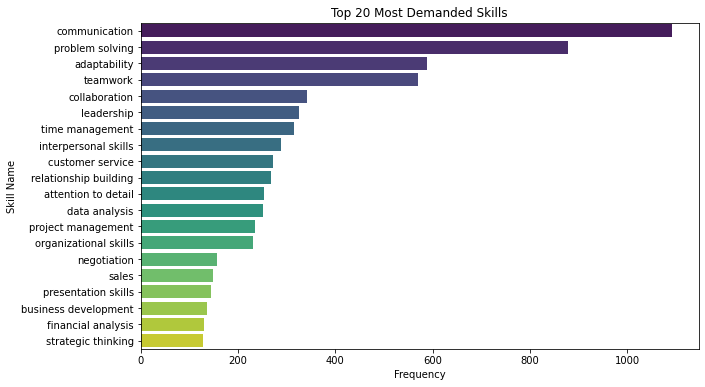

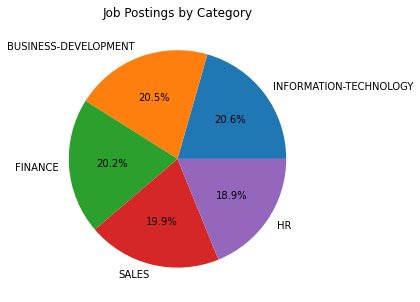

In [25]:
# 2.1 Top 20 Skills Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=skill_counts.head(20).values, y=skill_counts.head(20).index, palette='viridis')
plt.title("Top 20 Most Demanded Skills")
plt.xlabel("Frequency")
plt.ylabel("Skill Name")
plt.show()

# 2.2 Category Distribution
plt.figure(figsize=(10, 5))
df['category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Job Postings by Category")
plt.ylabel('')
plt.show()

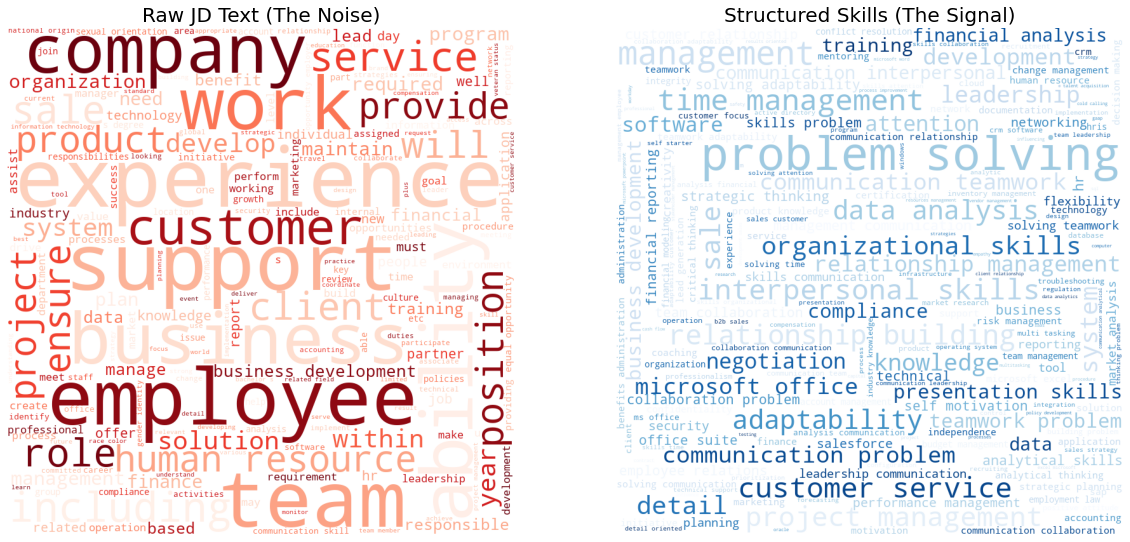

In [26]:
# 2.2 Visualization: The "Noise" vs. The "Signal"
def generate_clouds(df):
    # Signal: From Ground Truth Skills
    skill_text = " ".join([" ".join(skills) for skills in df['job_skill_set']])
    # Noise: From Raw Job Descriptions
    jd_text = " ".join(df['job_description'].str.lower().fillna(''))

    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    
    # Cloud 1: Raw JD Text
    wc_jd = WordCloud(width=800, height=800, background_color='white', colormap='Reds').generate(jd_text)
    ax[0].imshow(wc_jd)
    ax[0].set_title("Raw JD Text (The Noise)", fontsize=20)
    ax[0].axis('off')
    
    # Cloud 2: Extracted Skills
    wc_skill = WordCloud(width=800, height=800, background_color='white', colormap='Blues').generate(skill_text)
    ax[1].imshow(wc_skill)
    ax[1].set_title("Structured Skills (The Signal)", fontsize=20)
    ax[1].axis('off')
    
    plt.show()

generate_clouds(df)

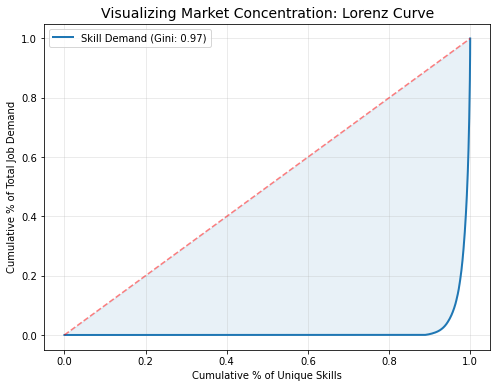

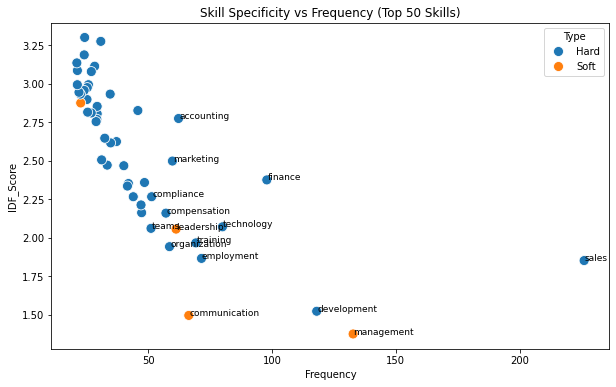

In [27]:
# 3.1 Lorenz Curve (Concentration Analysis)
def plot_lorenz_curve(counts):
    counts_sorted = np.sort(counts)
    cum_wealth = np.cumsum(counts_sorted) / np.sum(counts_sorted)
    cum_pop = np.arange(1, len(counts_sorted) + 1) / len(counts_sorted)
    gini = 1 - 2 * np.trapz(cum_wealth, cum_pop)
    
    plt.figure(figsize=(8, 6))
    plt.plot(cum_pop, cum_wealth, label=f'Skill Demand (Gini: {gini:.2f})', color='#1f77b4', lw=2)
    plt.plot([0, 1], [0, 1], '--', color='red', alpha=0.5)
    plt.fill_between(cum_pop, cum_pop, cum_wealth, alpha=0.1, color='#1f77b4')
    plt.title("Visualizing Market Concentration: Lorenz Curve", fontsize=14)
    plt.xlabel("Cumulative % of Unique Skills")
    plt.ylabel("Cumulative % of Total Job Demand")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_lorenz_curve(skill_stats['Frequency'])

# 3.2 Skill Specificity Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=skill_stats.head(50), x='Frequency', y='IDF_Score', hue='Type', s=100)
for i in range(15): # Label top 15 skills
    plt.text(skill_stats.Frequency.iloc[i]+0.2, skill_stats.IDF_Score.iloc[i], skill_stats.Skill.iloc[i], fontsize=9)
plt.title("Skill Specificity vs Frequency (Top 50 Skills)")
plt.show()

This Lorenz curve shows that skill demand is heavily skewed, with most cumulative demand concentrated in a very small share of skills.

Overall, the near-maximum Gini coefficient (0.97) indicates extreme inequality in the distribution of skill demand.


This scatter plot visualizes skills in a two-dimensional embedding space, where each point represents a skill and colors distinguish hard skills from soft skills to show how they cluster and relate to each other semantically.


### Baseline model implementation

### Baseline model 1: Rule-Based NER
**Pipeline:**

1. **Skill Extraction (Rule-Based NER)**
   Scans each job description for exact matches of skills from a predefined library using regex, assigns higher weights to skills found in the qualifications section, and predicts experience level based on seniority keywords.

2. **Model Execution**
   Applies the extraction function to all cleaned job descriptions and stores extracted skills, their weights, and predicted experience level as new dataframe columns.

3. **Performance Evaluation**
   Computes sample-level precision, recall, and F1-score by comparing extracted skills with ground-truth skill labels, then reports the mean metrics across all samples.

4. **Error Analysis (False Negatives)**
   Identifies skills present in ground truth but missed by the model and lists the most frequently missed ones to guide potential skill library expansion.

In [28]:
def extract_weighted_ner(text, library):
    text_lower = text.lower()
    # Split text into sections if possible
    qual_section = text_lower.split("qualifications")[-1] if "qualifications" in text_lower else text_lower
    
    extracted = []
    for skill in library:
        # Using regex to ensure whole-phrase matching
        if re.search(rf'\b{re.escape(skill)}\b', text_lower):
            importance = 1.5 if skill in qual_section else 1.0
            extracted.append({'skill': skill, 'importance': importance})
    
    # Extract Experience Level
    level = "Mid-Level"
    if re.search(r'\b(senior|sr|lead|manager|principal|6\+|7\+|10\+)\b', text_lower): level = "Advanced"
    elif re.search(r'\b(junior|jr|entry|intern|0-2|1-2)\b', text_lower): level = "Entry-Level"
    
    return [e['skill'] for e in extracted], [e['importance'] for e in extracted], level

# Execute Model
df['extracted_skills'], df['skill_weights'], df['pred_level'] = zip(*df['jd_clean'].apply(
    lambda x: extract_weighted_ner(x, full_skill_library)
))

This function performs rule-based skill extraction and simple experience-level classification from job descriptions.

For each job description, it scans the text for exact matches of skills from a predefined skill library using regex with word-boundary matching to avoid partial matches. If a skill appears in the “qualifications” section, it assigns a higher importance weight (1.5); otherwise, it assigns a default weight of 1.0. In addition, it infers the experience level (Entry-Level, Mid-Level, or Advanced) based on the presence of seniority-related keywords such as “senior,” “manager,” or “junior.”

Finally, the function is applied to the cleaned job description column, and the extracted skills, their corresponding weights, and the predicted experience level are stored as three new columns in the dataframe.


In [29]:
def calculate_sample_metrics(row):
    y_true = set(row['job_skill_set'])
    y_pred = set(row['extracted_skills'])
    
    tp = len(y_true.intersection(y_pred))
    precision = tp / len(y_pred) if y_pred else 0
    recall = tp / len(y_true) if y_true else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

df['p'], df['r'], df['f1'] = zip(*df.apply(calculate_sample_metrics, axis=1))

print(f"\n--- Final NER Baseline Performance ---")
print(f"Mean Precision: {df['p'].mean():.4f}")
print(f"Mean Recall:    {df['r'].mean():.4f}")
print(f"Mean F1-Score:  {df['f1'].mean():.4f}")

# 5.1 False Negative Analysis (What are we missing?)
missed_skills = []
for _, row in df.iterrows():
    missed_skills.extend(list(set(row['job_skill_set']) - set(row['extracted_skills'])))

if missed_skills:
    print("\nTop 5 Missed Skills (Potential for Library Expansion):")
    print(pd.Series(missed_skills).value_counts().head(5))


--- Final NER Baseline Performance ---
Mean Precision: 0.2771
Mean Recall:    0.4702
Mean F1-Score:  0.3358

Top 5 Missed Skills (Potential for Library Expansion):
problem solving          818
adaptability             563
teamwork                 513
communication            436
relationship building    242
Name: count, dtype: int64


In [15]:
df.head()

,job_id,category,job_title,job_description,job_skill_set,hard_skills_gt,soft_skills_gt,jd_clean,extracted_skills,skill_weights,pred_level,p,r,f1
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"[employee relations, talent acquisition, perfo...","[employee relations, talent acquisition, compe...","[performance management, analytical skills, co...",summary\nthe sr. hr generalist provides hr exp...,"[ada, administration, analytical skills, audit...","[1.5, 1.5, 1.5, 1.0, 1.5, 1.5, 1.5, 1.5, 1.0, ...",Advanced,0.223684,0.629630,0.330097
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"[Talent Acquisition, Employee Performance Mana...","[Talent Acquisition, Legal Compliance, Payroll...","[Employee Performance Management, Collaboratio...",be part of a stellar team at ysb as the manage...,"[administration, audits, background checks, co...","[1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, ...",Advanced,0.000000,0.000000,0.000000
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"[Human Resources Management, Recruitment, Empl...","[Recruitment, Employee Relations, Compliance w...","[Human Resources Management, Performance Manag...",our client is a thriving organization offering...,"[access, ada, administration, attention to det...","[1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, ...",Advanced,0.000000,0.000000,0.000000
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"[talent management, organizational development...","[organizational development, HR compliance, HR...","[talent management, performance management, le...",job title chief human resources officer chro...,"[administration, analytics, business administr...","[1.0, 1.5, 1.0, 1.0, 1.0, 1.5, 1.5, 1.5, 1.0, ...",Advanced,0.250000,0.666667,0.363636
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,"[Microsoft Office, Data analysis, Employee onb...","[Microsoft Office, Data analysis, Employee onb...","[Problem solving, Time management, Attention t...",description\n\n who we are \n\navi-spl is a di...,"[accounting, administration, affirmative actio...","[1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, ...",Mid-Level,0.000000,0.000000,0.000000


**Limitations:**
1. Keyword-based matching – Relies solely on exact string matches, missing synonyms, abbreviations, or context-specific mentions.
2. Case normalization only – Doesn’t handle variations like punctuation, plural forms, or word boundaries robustly beyond \b.
3. Simple section weighting – Only boosts skills in the “qualifications” section; ignores other cues like “responsibilities” or sentence context.
4. Experience level detection is naive – Regex rules may misclassify levels (e.g., “interned in senior project” → Advanced).
5. No semantic understanding – Cannot distinguish skill relevance or hierarchy; treats all matches equally except section boost.
6. Evaluation per sample – F1 calculation ignores skill importance weights, giving equal weight to all skills.
7. Scalability – As the library grows, regex matching can be slow, and maintaining large skill lists is cumbersome.

### Baseline Model 2: Statistical Keyword Extraction (TF-IDF + N-grams)
**Pipeline:**

1. N-gram Tokenization Instead of looking at single words, we generate sequences of 1, 2, and 3 words (Unigrams, Bigrams, Trigrams). This allows the model to "see" compound skills like "Machine Learning" or "Google Cloud Platform."

2. TF-IDF Vectorization We calculate the importance of each phrase. A skill gets a high score if it appears frequently in one JD but is relatively rare across the entire collection of JDs (filtering out "noise" words like "team" or "company").

3. Library-Constrained Filtering We cross-reference the top-scoring TF-IDF phrases against your full_skill_library to ensure we only extract valid professional skills.

4. Ranking and Selection We sort the matched skills by their TF-IDF scores, keeping only the most "relevant" ones for that specific job post.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

def extract_tfidf_skills(df, text_column, library, top_n=20):
    """
    Extracts skills using TF-IDF scores constrained by a skill library.
    """
    # 1. Initialize TF-IDF with Unigrams, Bigrams, and Trigrams
    # stop_words='english' removes common noise like 'and', 'the', etc.
    tfidf = TfidfVectorizer(
        ngram_range=(1, 3), 
        stop_words='english',
        lowercase=True
    )
    
    # 2. Fit and Transform the cleaned JDs
    tfidf_matrix = tfidf.fit_transform(df[text_column])
    feature_names = np.array(tfidf.get_feature_names_out())
    
    # 3. Create a set for O(1) library lookups
    skill_set = set(s.lower() for s in library)
    
    all_extracted = []
    all_weights = []

    # Iterate through each document's TF-IDF vector
    for i in range(tfidf_matrix.shape[0]):
        row_data = tfidf_matrix.getrow(i)
        
        # Get indices of non-zero elements and sort by score (descending)
        sorted_indices = row_data.indices[np.argsort(row_data.data)][::-1]
        
        current_doc_skills = []
        current_doc_weights = []
        
        for idx in sorted_indices:
            phrase = feature_names[idx]
            score = row_data[0, idx]
            
            # 4. Library-Constrained Filtering
            if phrase in skill_set:
                current_doc_skills.append(phrase)
                current_doc_weights.append(round(score, 4))
            
            # 5. Ranking and Selection (Limit to top_n to avoid noise)
            if len(current_doc_skills) >= top_n:
                break
                
        all_extracted.append(current_doc_skills)
        all_weights.append(current_doc_weights)
        
    return all_extracted, all_weights

# --- Execution ---
# Note: Ensure df['jd_clean'] and full_skill_library are defined
df['tfidf_skills'], df['tfidf_weights'] = extract_tfidf_skills(
    df, 
    'jd_clean', 
    full_skill_library
)

# Reuse your metrics function from Model 1
df['p2'], df['r2'], df['f1_2'] = zip(*df.apply(
    lambda row: calculate_sample_metrics({
        'job_skill_set': row['job_skill_set'], 
        'extracted_skills': row['tfidf_skills']
    }), axis=1)
)

print(f"--- Model 2 (TF-IDF) Performance ---")
print(f"Mean Precision: {df['p2'].mean():.4f}")
print(f"Mean Recall:    {df['r2'].mean():.4f}")
print(f"Mean F1-Score:  {df['f1_2'].mean():.4f}")

--- Model 2 (TF-IDF) Performance ---
Mean Precision: 0.3070
Mean Recall:    0.3222
Mean F1-Score:  0.3091


In [32]:
df.head()

,job_id,category,job_title,job_description,job_skill_set,jd_clean,hard_skills_gt,soft_skills_gt,extracted_skills,skill_weights,pred_level,p,r,f1,tfidf_skills,tfidf_weights,p2,r2,f1_2
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"[employee relations, talent acquisition, perfo...",summary\nthe sr. hr generalist provides hr exp...,"[employee relations, talent acquisition, compe...","[performance management, analytical skills, co...","[ada, administration, analytical skills, audit...","[1.5, 1.5, 1.5, 1.0, 1.5, 1.5, 1.5, 1.5, 1.0, ...",Advanced,0.315789,0.888889,0.466019,"[payroll, hr generalist, administration, payro...","[0.122, 0.0819, 0.0574, 0.0546, 0.0489, 0.0476...",0.40,0.296296,0.340426
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"[talent acquisition, employee performance mana...",be part of a stellar team at ysb as the manage...,"[talent acquisition, legal compliance, payroll...","[employee performance management, collaboratio...","[administration, audits, background checks, co...","[1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, ...",Advanced,0.166667,0.375000,0.230769,"[human resources, talent acquisition, complian...","[0.0632, 0.0461, 0.041, 0.0378, 0.0372, 0.0369...",0.20,0.250000,0.222222
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"[human resources management, recruitment, empl...",our client is a thriving organization offering...,"[recruitment, employee relations, compliance w...","[human resources management, performance manag...","[access, ada, administration, attention to det...","[1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, ...",Advanced,0.166667,0.450000,0.243243,"[human resources, ownership, management, testi...","[0.1045, 0.0314, 0.0305, 0.0302, 0.0288, 0.028...",0.20,0.200000,0.200000
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"[talent management, organizational development...",job title chief human resources officer chro...,"[organizational development, hr compliance, hr...","[talent management, performance management, le...","[administration, analytics, business administr...","[1.0, 1.5, 1.0, 1.0, 1.0, 1.5, 1.5, 1.5, 1.0, ...",Advanced,0.333333,0.888889,0.484848,"[human resources, talent management, healthcar...","[0.0859, 0.0572, 0.0531, 0.0522, 0.0495, 0.044...",0.35,0.388889,0.368421
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,"[microsoft office, data analysis, employee onb...",description\n\n who we are \n\navi-spl is a di...,"[microsoft office, data analysis, employee onb...","[problem solving, time management, attention t...","[accounting, administration, affirmative actio...","[1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, ...",Mid-Level,0.213115,0.650000,0.320988,"[organizational development, change management...","[0.0661, 0.0569, 0.0426, 0.0385, 0.0343, 0.034...",0.30,0.300000,0.300000


**Key Limitations:**

1. Exact Match Dependency: Like regex, TF-IDF cannot recognize that "Coding" and "Programming" mean the same thing. If the library says "Java Developer" but the JD says "Java Development," it might miss it if the N-gram doesn't align perfectly.

2. No Structural Awareness: TF-IDF treats the JD as a "Bag of Words." It doesn't know the difference between a skill you must have and a skill that is just "nice to have," unless those "must-have" skills appear more frequently.

3. Library Sensitivity: If your full_skill_library contains very common words (e.g., "Communication"), TF-IDF might give them a very low score because they appear in almost every JD, causing the model to filter them out even if they are in the ground truth.

**Future works:**
1. Expand the skill library to include more skills and improve the accuracy of skill extraction.
2. Implement a more sophisticated model, such as a deep learning-based NER model, to improve the performance of skill extraction.
3. Use more job post(without labeling data), implement self-supervise learning to improve the performance of skill extraction.